# Missing Value Analysis Across Three Customer Service Datasets

**Purpose:** Compare missing-value patterns across the three datasets being considered for the RL/Contextual Bandit project.

**Datasets:**
1. **Twitter Customer Support** (~2.8M tweets, 2017-2018)
2. **OpenAssistant Conversations** (oasst1, ~161K messages)
3. **Reddit DSTC8 Corpus** (~5M dialogues from 1,000 subreddits)

**Key Questions:**
- Which dataset has the most complete data?
- Which critical fields have missing values?
- Are there patterns in missingness that affect dataset usability?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

## 1. Load Twitter Dataset

In [3]:
twitter_path = r'B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\twitter\twcs\twcs.csv'
df_twitter = pd.read_csv(twitter_path)

print(f'Twitter dataset shape: {df_twitter.shape[0]:,} rows × {df_twitter.shape[1]} columns')
print(f'\nColumns: {list(df_twitter.columns)}')

Twitter dataset shape: 2,811,774 rows × 7 columns

Columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']


## 2. Load OpenAssistant Dataset

In [4]:
oasst_dir = r'B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\OpenAssistant Conversations Dataset'

try:
    df_oasst_train = pd.read_parquet(f'{oasst_dir}\\train.parquet', engine='fastparquet')
    df_oasst_val = pd.read_parquet(f'{oasst_dir}\\valid.parquet', engine='fastparquet')
    df_oasst = pd.concat([df_oasst_train, df_oasst_val], ignore_index=True)
    print(f'OpenAssistant dataset shape: {df_oasst.shape[0]:,} rows × {df_oasst.shape[1]} columns')
    print(f'\nColumns: {list(df_oasst.columns)}')
except Exception as e:
    print(f'Error loading OpenAssistant: {e}')
    print('Trying CSV files...')
    df_oasst_train = pd.read_csv(f'{oasst_dir}\\oasst1-train.csv')
    df_oasst_val = pd.read_csv(f'{oasst_dir}\\oasst1-val.csv')
    df_oasst = pd.concat([df_oasst_train, df_oasst_val], ignore_index=True)
    print(f'OpenAssistant dataset shape: {df_oasst.shape[0]:,} rows × {df_oasst.shape[1]} columns')
    print(f'\nColumns: {list(df_oasst.columns)}')

OpenAssistant dataset shape: 88,838 rows × 27 columns

Columns: ['message_id', 'parent_id', 'user_id', 'created_date', 'text', 'role', 'lang', 'review_count', 'review_result', 'deleted', 'rank', 'synthetic', 'model_name', 'message_tree_id', 'tree_state', 'detoxify.identity_attack', 'detoxify.insult', 'detoxify.obscene', 'detoxify.severe_toxicity', 'detoxify.sexual_explicit', 'detoxify.threat', 'detoxify.toxicity', 'emojis.count', 'emojis.name', 'labels.count', 'labels.name', 'labels.value']


## 3. Load Reddit Dataset (Sample)

**Note:** The full Reddit DSTC8 corpus is downloaded from HuggingFace. For missing value analysis, we'll load a sample from the training split.

In [5]:
# Option 1: If you have already downloaded and processed Reddit data
# Uncomment and modify path if you have a local CSV/parquet file
# df_reddit = pd.read_csv('path_to_reddit_data.csv')

# Option 2: Download from HuggingFace (will use cache if already downloaded)
try:
    from huggingface_hub import hf_hub_download
    import zipfile
    import json
    
    print('Downloading Reddit DSTC8 training data...')
    zip_path = hf_hub_download('roskoN/dstc8-reddit-corpus', filename='training.zip', repo_type='dataset')
    print(f'Downloaded to: {zip_path}')
    
    # Extract and parse (load sample to avoid memory issues)
    records = []
    with zipfile.ZipFile(zip_path, 'r') as z:
        files = [f for f in z.namelist() if f.endswith('.json')]
        print(f'Found {len(files)} JSON files. Loading first 100,000 conversations...')
        
        for json_file in files[:5]:  # Load first 5 files for speed
            with z.open(json_file) as f:
                for line_num, line in enumerate(f):
                    if line_num >= 20000:  # Limit per file
                        break
                    records.append(json.loads(line.decode('utf-8')))
            if len(records) >= 100000:
                break
    
    df_reddit = pd.DataFrame(records)
    print(f'\nReddit dataset shape: {df_reddit.shape[0]:,} rows × {df_reddit.shape[1]} columns')
    print(f'\nColumns: {list(df_reddit.columns)}')
    
except Exception as e:
    print(f'Could not load Reddit dataset: {e}')
    print('Skipping Reddit in comparison.')
    df_reddit = None

Downloaded to: C:\Users\PC\.cache\huggingface\hub\datasets--roskoN--dstc8-reddit-corpus\snapshots\b43be7fa91a2d03f72682cca175ec5271d89b880\training.zip
Found 0 JSON files. Loading first 100,000 conversations...

Reddit dataset shape: 0 rows × 0 columns

Columns: []


## 4. Calculate Missing Value Statistics

In [6]:
def get_missing_stats(df, dataset_name):
    """Calculate missing value statistics for a dataset."""
    missing = pd.DataFrame({
        'Dataset': dataset_name,
        'Column': df.columns,
        'Missing_Count': df.isnull().sum().values,
        'Missing_Pct': (df.isnull().sum().values / len(df) * 100).round(2),
        'Total_Rows': len(df)
    })
    return missing.sort_values('Missing_Pct', ascending=False)

# Calculate for all datasets
twitter_missing = get_missing_stats(df_twitter, 'Twitter')
oasst_missing = get_missing_stats(df_oasst, 'OpenAssistant')

if df_reddit is not None:
    reddit_missing = get_missing_stats(df_reddit, 'Reddit')
    all_missing = pd.concat([twitter_missing, oasst_missing, reddit_missing], ignore_index=True)
else:
    all_missing = pd.concat([twitter_missing, oasst_missing], ignore_index=True)

print('Missing value statistics calculated for all datasets.')

Missing value statistics calculated for all datasets.


## 5. Twitter Dataset - Missing Values

In [7]:
print('=== TWITTER CUSTOMER SUPPORT DATASET ===')
print(f'Total rows: {len(df_twitter):,}\n')
print(twitter_missing[twitter_missing['Missing_Pct'] > 0].to_string(index=False))
print(f'\nColumns with 0% missing: {(twitter_missing["Missing_Pct"] == 0).sum()}')
print(f'Columns with >0% missing: {(twitter_missing["Missing_Pct"] > 0).sum()}')

=== TWITTER CUSTOMER SUPPORT DATASET ===
Total rows: 2,811,774

Dataset                  Column  Missing_Count  Missing_Pct  Total_Rows
Twitter       response_tweet_id        1040629        37.01     2811774
Twitter in_response_to_tweet_id         794335        28.25     2811774

Columns with 0% missing: 5
Columns with >0% missing: 2


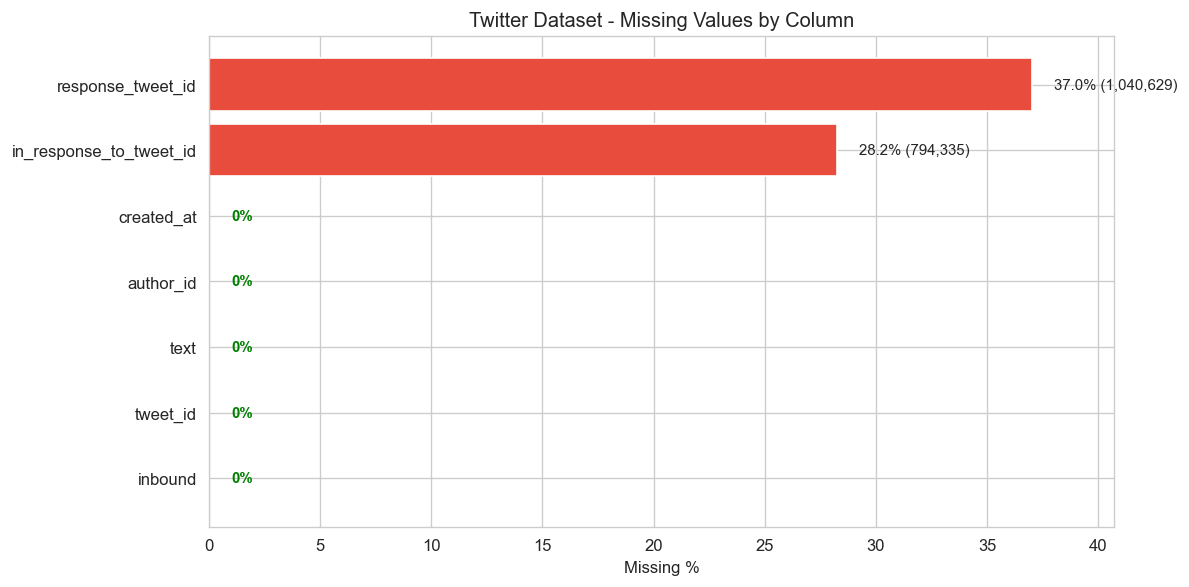

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
twitter_plot = twitter_missing[twitter_missing['Missing_Pct'] >= 0].sort_values('Missing_Pct', ascending=True)
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in twitter_plot['Missing_Pct']]

ax.barh(twitter_plot['Column'], twitter_plot['Missing_Pct'], color=colors, edgecolor='white')
ax.set_xlabel('Missing %')
ax.set_title('Twitter Dataset - Missing Values by Column')
ax.set_xlim(0, max(twitter_plot['Missing_Pct']) * 1.1 if twitter_plot['Missing_Pct'].max() > 0 else 10)

# Add value labels
for i, (col, pct, cnt) in enumerate(zip(twitter_plot['Column'], twitter_plot['Missing_Pct'], twitter_plot['Missing_Count'])):
    if pct > 0:
        ax.text(pct + 1, i, f'{pct:.1f}% ({cnt:,})', va='center', fontsize=9)
    else:
        ax.text(1, i, '0%', va='center', fontsize=9, color='green', weight='bold')

plt.tight_layout()
plt.show()

## 6. OpenAssistant Dataset - Missing Values

In [9]:
print('=== OPENASSISTANT CONVERSATIONS DATASET ===')
print(f'Total rows: {len(df_oasst):,}\n')
print(oasst_missing[oasst_missing['Missing_Pct'] > 0].to_string(index=False))
print(f'\nColumns with 0% missing: {(oasst_missing["Missing_Pct"] == 0).sum()}')
print(f'Columns with >0% missing: {(oasst_missing["Missing_Pct"] > 0).sum()}')

=== OPENASSISTANT CONVERSATIONS DATASET ===
Total rows: 88,838

      Dataset                   Column  Missing_Count  Missing_Pct  Total_Rows
OpenAssistant               model_name          88838       100.00       88838
OpenAssistant                     rank          37575        42.30       88838
OpenAssistant             emojis.count          13523        15.22       88838
OpenAssistant              emojis.name          13523        15.22       88838
OpenAssistant detoxify.identity_attack          12745        14.35       88838
OpenAssistant          detoxify.threat          12745        14.35       88838
OpenAssistant detoxify.severe_toxicity          12745        14.35       88838
OpenAssistant         detoxify.obscene          12745        14.35       88838
OpenAssistant          detoxify.insult          12745        14.35       88838
OpenAssistant detoxify.sexual_explicit          12745        14.35       88838
OpenAssistant        detoxify.toxicity          12745        14.35 

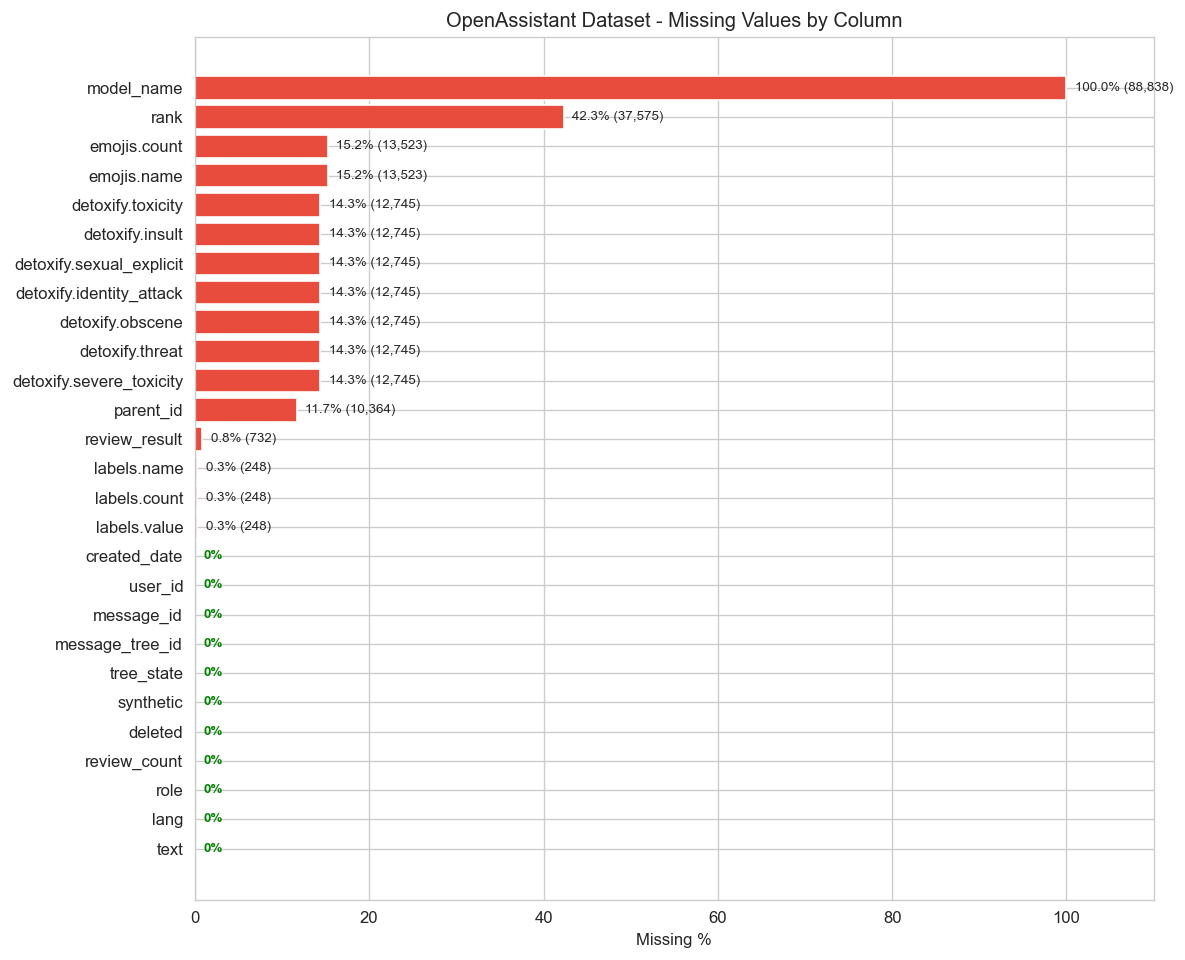

In [10]:
fig, ax = plt.subplots(figsize=(10, max(6, len(oasst_missing) * 0.3)))
oasst_plot = oasst_missing.sort_values('Missing_Pct', ascending=True)
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in oasst_plot['Missing_Pct']]

ax.barh(oasst_plot['Column'], oasst_plot['Missing_Pct'], color=colors, edgecolor='white')
ax.set_xlabel('Missing %')
ax.set_title('OpenAssistant Dataset - Missing Values by Column')
ax.set_xlim(0, max(oasst_plot['Missing_Pct']) * 1.1 if oasst_plot['Missing_Pct'].max() > 0 else 10)

# Add value labels
for i, (col, pct, cnt) in enumerate(zip(oasst_plot['Column'], oasst_plot['Missing_Pct'], oasst_plot['Missing_Count'])):
    if pct > 0:
        ax.text(pct + 1, i, f'{pct:.1f}% ({cnt:,})', va='center', fontsize=8)
    else:
        ax.text(1, i, '0%', va='center', fontsize=8, color='green', weight='bold')

plt.tight_layout()
plt.show()

## 7. Reddit Dataset - Missing Values

In [11]:
if df_reddit is not None:
    print('=== REDDIT DSTC8 CORPUS (SAMPLE) ===')
    print(f'Total rows: {len(df_reddit):,}\n')
    print(reddit_missing[reddit_missing['Missing_Pct'] > 0].to_string(index=False))
    print(f'\nColumns with 0% missing: {(reddit_missing["Missing_Pct"] == 0).sum()}')
    print(f'Columns with >0% missing: {(reddit_missing["Missing_Pct"] > 0).sum()}')
else:
    print('Reddit dataset not loaded - skipping.')

=== REDDIT DSTC8 CORPUS (SAMPLE) ===
Total rows: 0

Empty DataFrame
Columns: [Dataset, Column, Missing_Count, Missing_Pct, Total_Rows]
Index: []

Columns with 0% missing: 0
Columns with >0% missing: 0


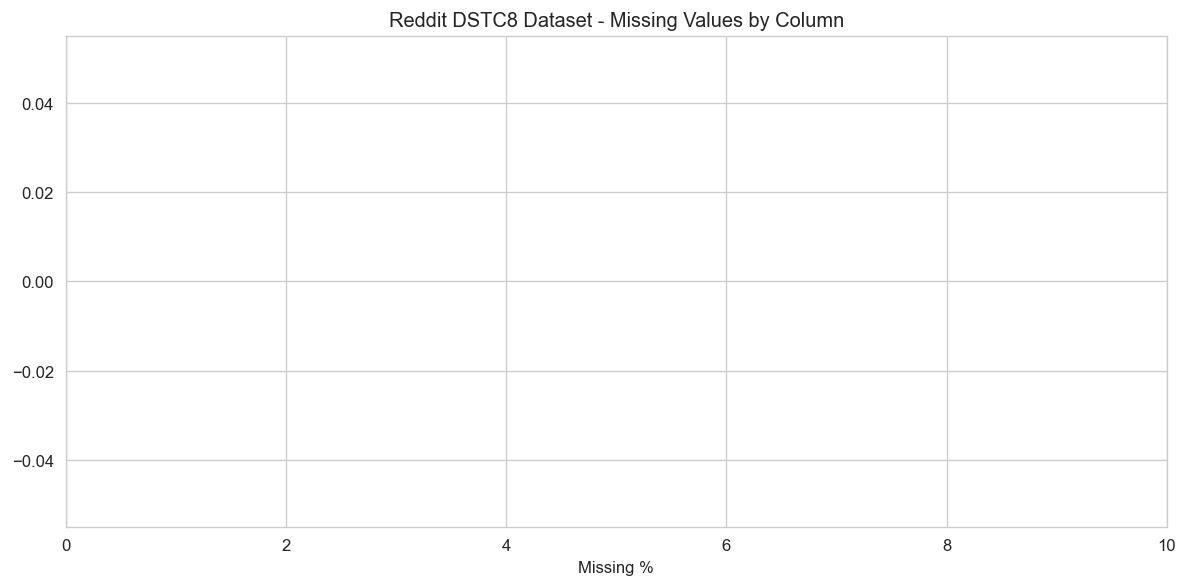

In [12]:
if df_reddit is not None:
    fig, ax = plt.subplots(figsize=(10, max(5, len(reddit_missing) * 0.3)))
    reddit_plot = reddit_missing.sort_values('Missing_Pct', ascending=True)
    colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in reddit_plot['Missing_Pct']]
    
    ax.barh(reddit_plot['Column'], reddit_plot['Missing_Pct'], color=colors, edgecolor='white')
    ax.set_xlabel('Missing %')
    ax.set_title('Reddit DSTC8 Dataset - Missing Values by Column')
    ax.set_xlim(0, max(reddit_plot['Missing_Pct']) * 1.1 if reddit_plot['Missing_Pct'].max() > 0 else 10)
    
    # Add value labels
    for i, (col, pct, cnt) in enumerate(zip(reddit_plot['Column'], reddit_plot['Missing_Pct'], reddit_plot['Missing_Count'])):
        if pct > 0:
            ax.text(pct + 1, i, f'{pct:.1f}% ({cnt:,})', va='center', fontsize=8)
        else:
            ax.text(1, i, '0%', va='center', fontsize=8, color='green', weight='bold')
    
    plt.tight_layout()
    plt.show()

## 8. Cross-Dataset Comparison

In [13]:
# Overall completeness by dataset
dataset_summary = all_missing.groupby('Dataset').agg({
    'Missing_Pct': 'mean',
    'Column': 'count',
    'Total_Rows': 'first'
}).reset_index()
dataset_summary.columns = ['Dataset', 'Avg_Missing_Pct', 'Num_Columns', 'Total_Rows']
dataset_summary['Completeness_Pct'] = (100 - dataset_summary['Avg_Missing_Pct']).round(2)

print('=== DATASET COMPLETENESS SUMMARY ===')
print(dataset_summary.to_string(index=False))

=== DATASET COMPLETENESS SUMMARY ===
      Dataset  Avg_Missing_Pct  Num_Columns  Total_Rows  Completeness_Pct
OpenAssistant        10.611852           27       88838             89.39
      Twitter         9.322857            7     2811774             90.68


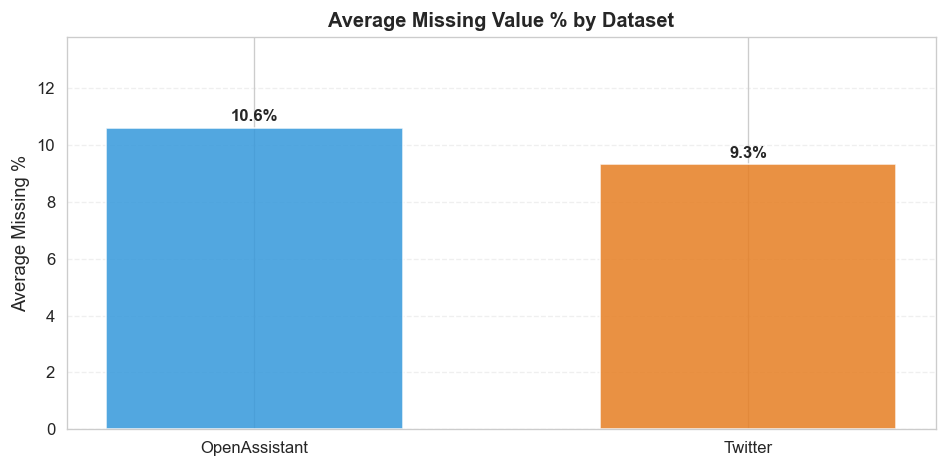

In [21]:
# Compact visualization: Average missing value % comparison
fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#3498db', '#e67e22', '#2ecc71'][:len(dataset_summary)]

# Create bar heights, ensuring 0% values get a small visible height
bar_heights = []
for val in dataset_summary['Avg_Missing_Pct']:
    if val == 0:
        bar_heights.append(0.2)  # Small visible height for 0% values
    else:
        bar_heights.append(val)

bars = ax.bar(dataset_summary['Dataset'], bar_heights, 
              color=colors, edgecolor='white', alpha=0.85, width=0.6)

ax.set_ylabel('Average Missing %', fontsize=11)
ax.set_title('Average Missing Value % by Dataset', fontsize=12, weight='bold')

# Set appropriate y-axis limits
max_val = max(dataset_summary['Avg_Missing_Pct'])
if max_val == 0:
    ax.set_ylim(0, 2)
else:
    ax.set_ylim(0, max(max_val * 1.3, 1))  # Ensure minimum range to show 0% values

ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (ds, val) in enumerate(zip(dataset_summary['Dataset'], dataset_summary['Avg_Missing_Pct'])):
    if val == 0:
        # For 0% values, place text in green and position it on the small bar
        ax.text(i, 0.3, f'{val:.1f}%', ha='center', fontsize=10, weight='bold', color='green')
    else:
        ax.text(i, val + (max_val * 0.02), f'{val:.1f}%', ha='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

In [15]:
# Count columns by missing category
def categorize_missing(pct):
    if pct == 0:
        return 'Complete (0%)'
    elif pct < 5:
        return 'Minimal (<5%)'
    elif pct < 25:
        return 'Moderate (5-25%)'
    elif pct < 50:
        return 'High (25-50%)'
    else:
        return 'Critical (>50%)'

all_missing['Missing_Category'] = all_missing['Missing_Pct'].apply(categorize_missing)

category_counts = all_missing.groupby(['Dataset', 'Missing_Category']).size().unstack(fill_value=0)
category_order = ['Complete (0%)', 'Minimal (<5%)', 'Moderate (5-25%)', 'High (25-50%)', 'Critical (>50%)']
category_counts = category_counts.reindex(columns=[c for c in category_order if c in category_counts.columns])

print('\n=== COLUMNS BY MISSING VALUE CATEGORY ===')
print(category_counts)


=== COLUMNS BY MISSING VALUE CATEGORY ===
Missing_Category  Complete (0%)  Minimal (<5%)  Moderate (5-25%)  \
Dataset                                                            
OpenAssistant                11              4                10   
Twitter                       5              0                 0   

Missing_Category  High (25-50%)  Critical (>50%)  
Dataset                                           
OpenAssistant                 1                1  
Twitter                       2                0  


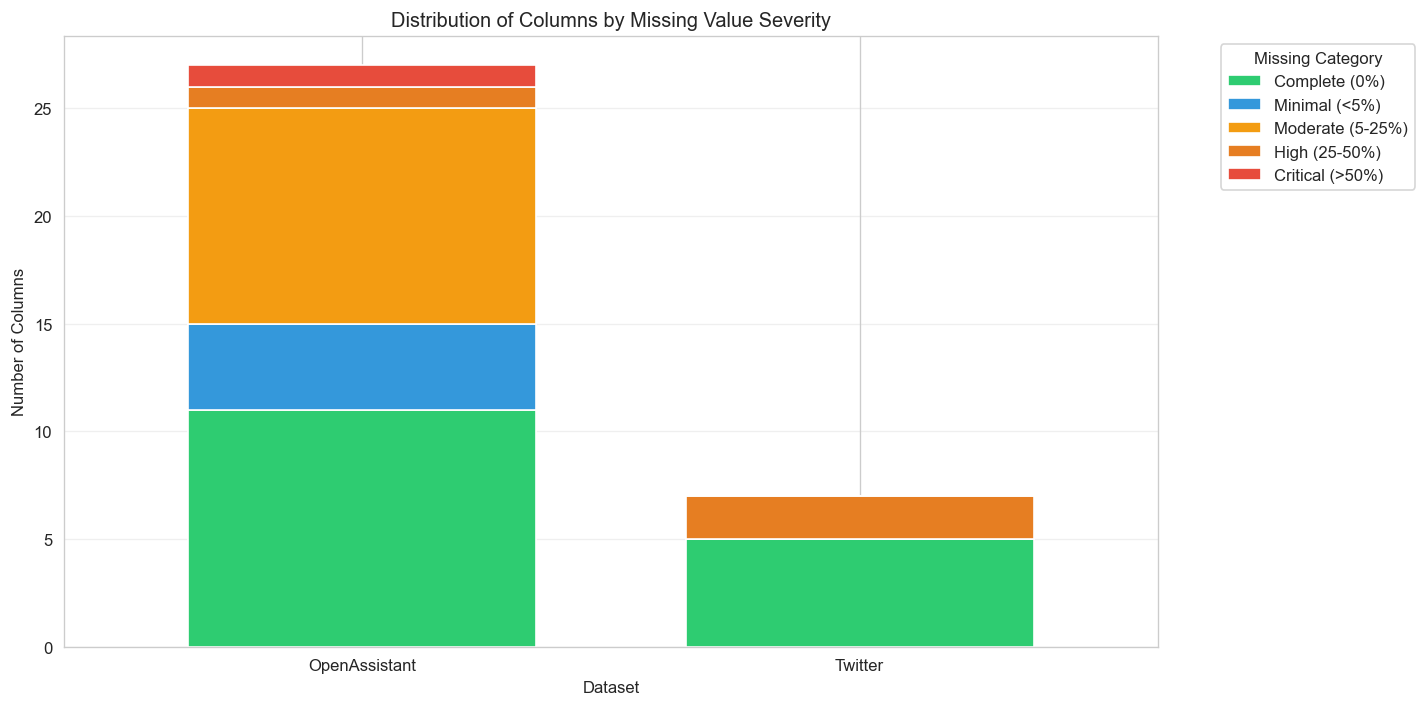

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

category_counts.plot.bar(stacked=True, ax=ax, 
                         color=['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c'],
                         edgecolor='white', width=0.7)
ax.set_xlabel('Dataset')
ax.set_ylabel('Number of Columns')
ax.set_title('Distribution of Columns by Missing Value Severity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Missing Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Key Findings & Recommendations

In [17]:
print('\n' + '='*70)
print('KEY FINDINGS: MISSING VALUE ANALYSIS')
print('='*70)

for dataset_name in dataset_summary['Dataset']:
    ds_data = all_missing[all_missing['Dataset'] == dataset_name]
    ds_info = dataset_summary[dataset_summary['Dataset'] == dataset_name].iloc[0]
    
    print(f'\n{dataset_name.upper()}')
    print('-' * 70)
    print(f'  Total Rows: {ds_info["Total_Rows"]:,}')
    print(f'  Total Columns: {int(ds_info["Num_Columns"])}')
    print(f'  Overall Completeness: {ds_info["Completeness_Pct"]:.2f}%')
    print(f'  Average Missing: {ds_info["Avg_Missing_Pct"]:.2f}%')
    
    complete_cols = (ds_data['Missing_Pct'] == 0).sum()
    missing_cols = (ds_data['Missing_Pct'] > 0).sum()
    critical_cols = (ds_data['Missing_Pct'] > 50).sum()
    
    print(f'  ✓ Complete columns: {complete_cols}')
    print(f'  ⚠ Columns with missing data: {missing_cols}')
    if critical_cols > 0:
        print(f'  ⛔ Critical (>50% missing): {critical_cols}')
        print(f'     Critical columns: {list(ds_data[ds_data["Missing_Pct"] > 50]["Column"])}')

print('\n' + '='*70)
print('RECOMMENDATIONS FOR RL PROJECT')
print('='*70)

# Dataset-specific recommendations
twitter_info = dataset_summary[dataset_summary['Dataset'] == 'Twitter'].iloc[0]
oasst_info = dataset_summary[dataset_summary['Dataset'] == 'OpenAssistant'].iloc[0]

best_dataset = dataset_summary.loc[dataset_summary['Completeness_Pct'].idxmax(), 'Dataset']
print(f'\n✅ Most complete dataset: {best_dataset} ({dataset_summary[dataset_summary["Dataset"] == best_dataset].iloc[0]["Completeness_Pct"]:.1f}% complete)')

if twitter_info['Completeness_Pct'] >= 95:
    print(f'\n✅ Twitter dataset has excellent completeness ({twitter_info["Completeness_Pct"]:.1f}%)')
    print('   → Recommended for RL training (large scale + minimal missing data)')
elif twitter_info['Completeness_Pct'] >= 85:
    print(f'\n⚠ Twitter dataset has good completeness ({twitter_info["Completeness_Pct"]:.1f}%)')
    print('   → Usable but check critical fields for imputation strategy')
else:
    print(f'\n⚠ Twitter dataset has moderate completeness ({twitter_info["Completeness_Pct"]:.1f}%)')
    print('   → May require significant preprocessing/imputation')

print('\n' + '='*70)


KEY FINDINGS: MISSING VALUE ANALYSIS

OPENASSISTANT
----------------------------------------------------------------------
  Total Rows: 88,838
  Total Columns: 27
  Overall Completeness: 89.39%
  Average Missing: 10.61%
  ✓ Complete columns: 11
  ⚠ Columns with missing data: 16
  ⛔ Critical (>50% missing): 1
     Critical columns: ['model_name']

TWITTER
----------------------------------------------------------------------
  Total Rows: 2,811,774
  Total Columns: 7
  Overall Completeness: 90.68%
  Average Missing: 9.32%
  ✓ Complete columns: 5
  ⚠ Columns with missing data: 2

RECOMMENDATIONS FOR RL PROJECT

✅ Most complete dataset: Twitter (90.7% complete)

⚠ Twitter dataset has good completeness (90.7%)
   → Usable but check critical fields for imputation strategy



## 10. Export Summary Table

In [18]:
# Create comprehensive summary table
summary_export = all_missing[all_missing['Missing_Pct'] > 0][['Dataset', 'Column', 'Missing_Pct', 'Missing_Count']].copy()
summary_export = summary_export.sort_values(['Dataset', 'Missing_Pct'], ascending=[True, False])

print('\n=== FIELDS WITH MISSING DATA (SORTED BY SEVERITY) ===')
print(summary_export.to_string(index=False))

# Optional: Save to CSV
output_path = r'B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\summaryStatsDataset\missing_values_report.csv'
summary_export.to_csv(output_path, index=False)
print(f'\n✅ Summary exported to: {output_path}')


=== FIELDS WITH MISSING DATA (SORTED BY SEVERITY) ===
      Dataset                   Column  Missing_Pct  Missing_Count
OpenAssistant               model_name       100.00        88838.0
OpenAssistant                     rank        42.30        37575.0
OpenAssistant             emojis.count        15.22        13523.0
OpenAssistant              emojis.name        15.22        13523.0
OpenAssistant detoxify.identity_attack        14.35        12745.0
OpenAssistant          detoxify.threat        14.35        12745.0
OpenAssistant detoxify.severe_toxicity        14.35        12745.0
OpenAssistant         detoxify.obscene        14.35        12745.0
OpenAssistant          detoxify.insult        14.35        12745.0
OpenAssistant detoxify.sexual_explicit        14.35        12745.0
OpenAssistant        detoxify.toxicity        14.35        12745.0
OpenAssistant                parent_id        11.67        10364.0
OpenAssistant            review_result         0.82          732.0
OpenAss